In [9]:
# ============================================================
# BÀI TẬP 1: CNN NHẬN DẠNG ẢNH CIFAR-10
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout

In [10]:
# ============================================================
# 1. Đọc dữ liệu CIFAR-10
# ============================================================

(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

# Tên 10 lớp của CIFAR-10
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

num_classes = 10
input_shape = (32, 32, 3)

X_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
X_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


In [11]:
# ============================================================
# 2. Chuẩn hóa dữ liệu ảnh
# ============================================================

# Pixel ban đầu nằm trong [0, 255]
# Chia 255 để đưa về [0, 1]
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("X_train sau chuẩn hóa:", X_train.shape)
print("X_test sau chuẩn hóa:", X_test.shape)

X_train sau chuẩn hóa: (50000, 32, 32, 3)
X_test sau chuẩn hóa: (10000, 32, 32, 3)


In [12]:
# ============================================================
# 3. Chuyển nhãn sang one-hot encoding
# ============================================================

y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

print("y_train sau one-hot:", y_train.shape)
print("y_test sau one-hot:", y_test.shape)

y_train sau one-hot: (50000, 10)
y_test sau one-hot: (10000, 10)


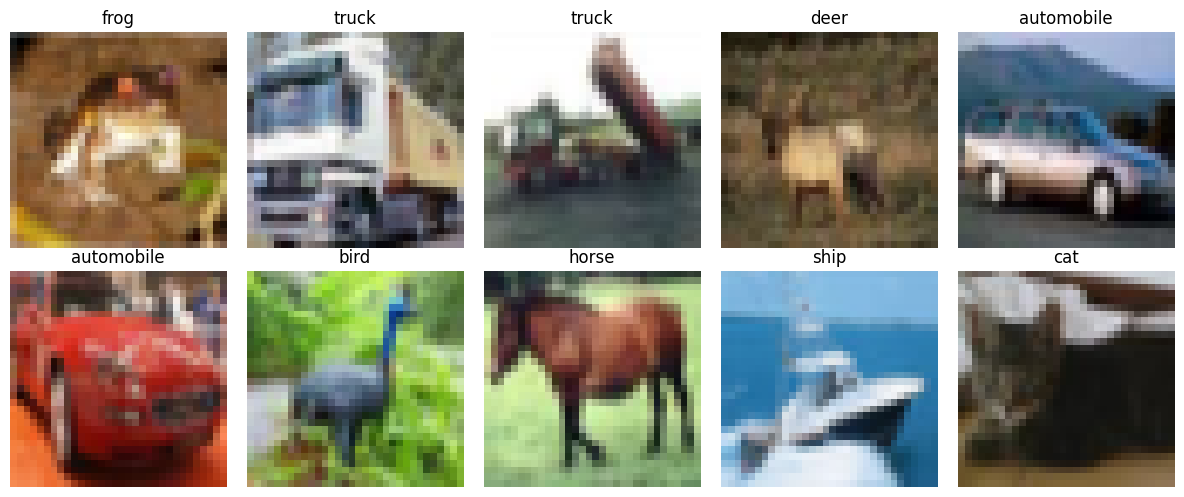

In [13]:
# ============================================================
# 4. Trực quan hóa 10 ảnh đầu tiên
# ============================================================

plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    label_index = np.argmax(y_train[i])
    plt.title(class_names[label_index])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# 5. Xây dựng mô hình CNN cho CIFAR-10
# ============================================================

model = Sequential()

# Block 1
model.add(Conv2D(
    filters=32,
    kernel_size=(3, 3),
    activation="relu",
    padding="same",
    input_shape=input_shape
))
model.add(Conv2D(
    filters=32,
    kernel_size=(3, 3),
    activation="relu",
    padding="same"
))
model.add(MaxPool2D(pool_size=(2, 2)))

# Block 2
model.add(Conv2D(
    filters=64,
    kernel_size=(3, 3),
    activation="relu",
    padding="same"
))
model.add(Conv2D(
    filters=64,
    kernel_size=(3, 3),
    activation="relu",
    padding="same"
))
model.add(MaxPool2D(pool_size=(2, 2)))

# Block 3
model.add(Conv2D(
    filters=128,
    kernel_size=(3, 3),
    activation="relu",
    padding="same"
))
model.add(MaxPool2D(pool_size=(2, 2)))

# Fully Connected
model.add(Flatten())
model.add(Dense(128, activation="relu"))
model.add(Dropout(0.5))

# Output layer
model.add(Dense(num_classes, activation="softmax"))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,986 (1.54 MB)

 Trainable params: 402,986 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# ============================================================
# 6. Compile mô hình
# ============================================================

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)    

In [19]:
# ============================================================
# 7. Huấn luyện mô hình
# ============================================================

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 236s 374ms/step - accuracy: 0.3608 - loss: 1.7267 - val_accuracy: 0.5276 - val_loss: 1.2924
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 239s 383ms/step - accuracy: 0.5403 - loss: 1.2831 - val_accuracy: 0.6343 - val_loss: 1.0438
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 243s 388ms/step - accuracy: 0.6208 - loss: 1.0806 - val_accuracy: 0.6897 - val_loss: 0.8866
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 261s 386ms/step - accuracy: 0.6705 - loss: 0.9538 - val_accuracy: 0.6976 - val_loss: 0.8717
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 244s 390ms/step - accuracy: 0.7047 - loss: 0.8501 - val_accuracy: 0.7313 - val_loss: 0.7820
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 261s 388ms/step - accuracy: 0.7312 - loss: 0.7724 - val_accuracy: 0.7285 - val_loss: 0.8007
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 242s 387ms/step - accuracy: 0.7512 - loss: 0.7203 - val_accuracy: 0.7509 - val_loss: 0.7263
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 241s 385ms/step - accuracy: 0.7713 -

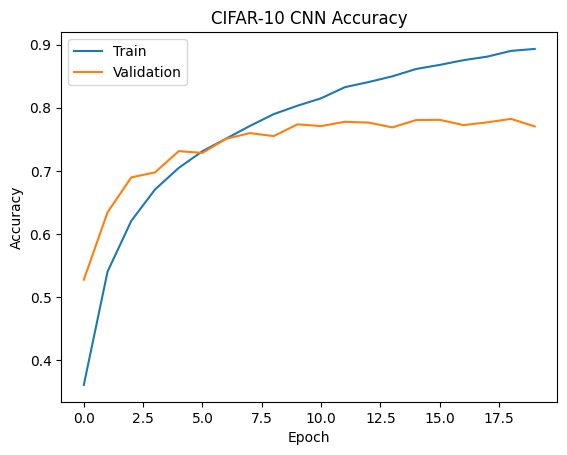

In [20]:
# ============================================================
# 8. Vẽ biểu đồ accuracy
# ============================================================

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("CIFAR-10 CNN Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"], loc="upper left")
plt.show()

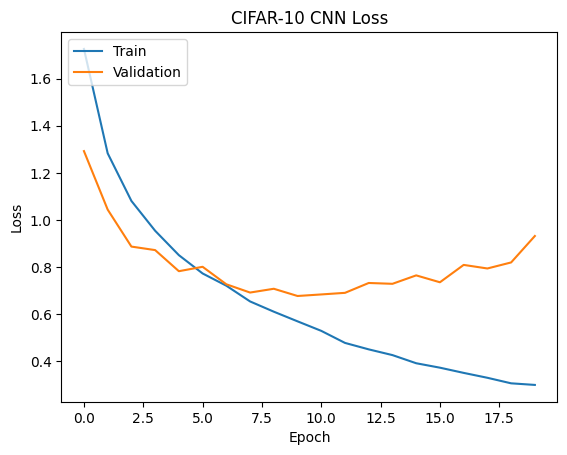

In [21]:
# ============================================================
# 9. Vẽ biểu đồ loss
# ============================================================

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("CIFAR-10 CNN Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"], loc="upper left")
plt.show()

In [22]:
# ============================================================
# 10. Đánh giá mô hình trên tập test
# ============================================================

score = model.evaluate(X_test, y_test, verbose=1)

print("Test loss:", score[0])
print("Test accuracy:", score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.7644 - loss: 0.9735
Test loss: 0.9734942317008972
Test accuracy: 0.7644000053405762


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
Nhãn thật: cat
Nhãn dự báo: cat
Vector xác suất:
[[4.1929933e-08 4.0884671e-10 1.4314601e-07 9.9299484e-01 2.1868427e-06
  6.8860846e-03 7.5783348e-05 6.6898394e-07 4.0209557e-05 1.7335301e-08]]


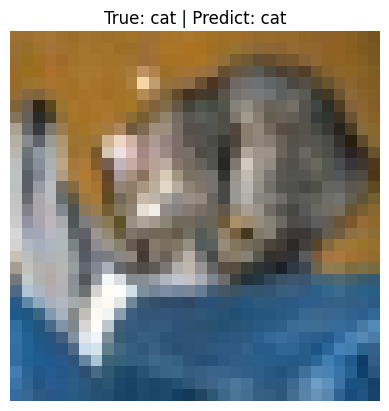

In [23]:
# ============================================================
# 11. Dự báo thử một ảnh trong tập test
# ============================================================

index = 0

image = X_test[index]
true_label = np.argmax(y_test[index])

predict = model.predict(image.reshape(1, 32, 32, 3))
predicted_label = np.argmax(predict)

print("Nhãn thật:", class_names[true_label])
print("Nhãn dự báo:", class_names[predicted_label])
print("Vector xác suất:")
print(predict)

plt.imshow(image)
plt.title(f"True: {class_names[true_label]} | Predict: {class_names[predicted_label]}")
plt.axis("off")
plt.show()

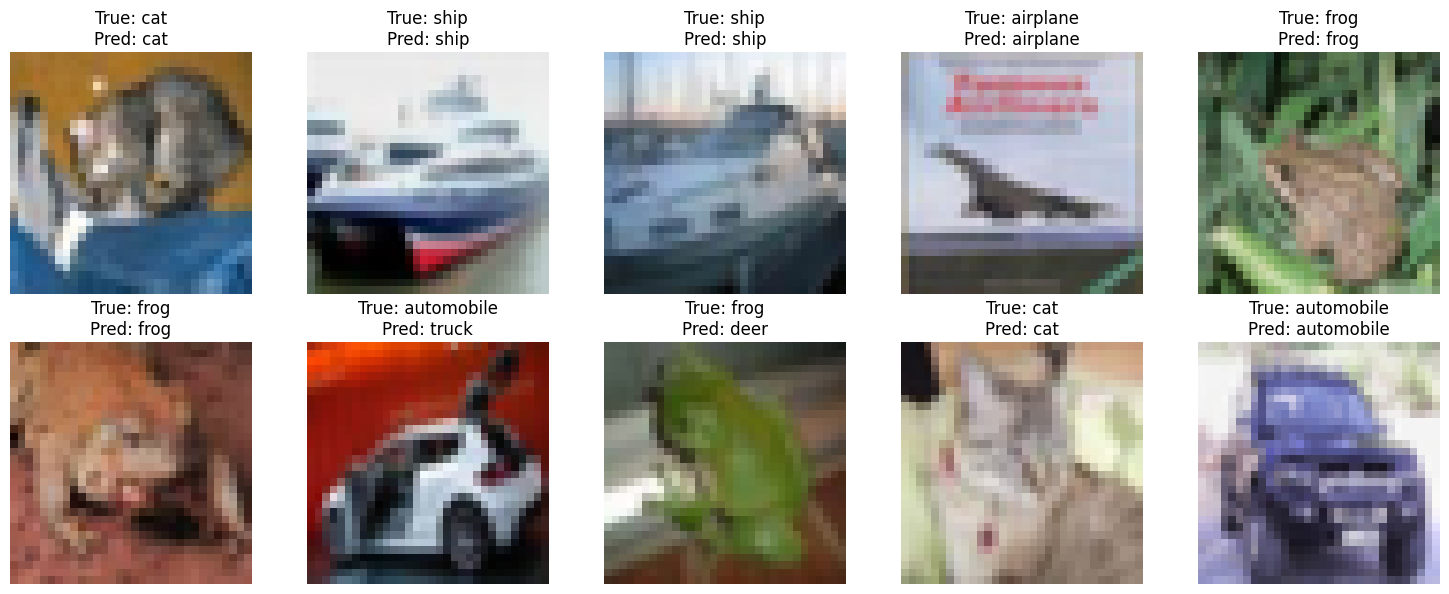

In [24]:
# ============================================================
# 12. Dự báo 10 ảnh đầu tiên trong tập test
# ============================================================

plt.figure(figsize=(15, 6))

for i in range(10):
    image = X_test[i]
    true_label = np.argmax(y_test[i])

    predict = model.predict(image.reshape(1, 32, 32, 3), verbose=0)
    predicted_label = np.argmax(predict)

    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.title(
        f"True: {class_names[true_label]}\nPred: {class_names[predicted_label]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [25]:
# ============================================================
# 13. Lưu mô hình
# ============================================================

model.save("cnn_cifar10_model.keras")

print("Đã lưu mô hình vào file cnn_cifar10_model.keras")

Đã lưu mô hình vào file cnn_cifar10_model.keras


In [26]:
# ============================================================
# 14. Nạp lại mô hình đã lưu
# ============================================================

loaded_model = keras.models.load_model("cnn_cifar10_model.keras")

score = loaded_model.evaluate(X_test, y_test, verbose=1)

print("Loaded model test loss:", score[0])
print("Loaded model test accuracy:", score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 49ms/step - accuracy: 0.7644 - loss: 0.9735
Loaded model test loss: 0.9734942317008972
Loaded model test accuracy: 0.7644000053405762
